In [1]:
# Installazione delle librerie Python necessarie per il progetto
%pip install ucimlrepo matplotlib scikit-learn pandas keras numpy tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Analisi Dataset

Setup iniziale per la creazione della directory dove salvare le visualizzazioni generate durante l'analisi.

In [2]:
import os

# Crea la cartella per salvare i grafici generati
os.makedirs("images", exist_ok=True)

Caricamento del dataset dal repository UCI e preparazione del DataFrame per l'analisi esplorativa.

In [3]:
from ucimlrepo import fetch_ucirepo
import numpy as np

# Scarica il dataset diabetes (ID 891) dal repository UCI
dataset = fetch_ucirepo(id=891)

# Estrae il DataFrame completo con tutte le colonne
df = dataset.data.original

Analisi preliminare dei tipi di dati e delle statistiche descrittive per comprendere la struttura del dataset.

In [4]:
# Mostra i tipi di dato di ciascuna feature
df.dtypes

ID                      int64
Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [5]:
# Calcola le statistiche descrittive (media, std, min, max, quartili)
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Preparazione delle feature per il machine learning rimuovendo colonne non predittive e isolando la variabile target.

In [6]:
# Rimuove ID (non predittivo) e target (da predire) per ottenere solo le features
features = df.drop(columns=["ID", "Diabetes_binary"])
features.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

Identificazione delle feature numeriche e analisi della distribuzione delle classi target per valutare lo sbilanciamento.

In [7]:
# Seleziona solo le colonne di tipo int64 (numeriche)
numeric_features = features.select_dtypes(["int64"]).columns
FEATURES_NUMBER = len(numeric_features)  # Salva il numero totale di feature
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [8]:
# Conta il numero di istanze per ogni classe (0: no diabete, 1: diabete)
print("Number of instances for each class:")
print(df["Diabetes_binary"].value_counts())

Number of instances for each class:
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64


In [9]:
# Calcola la distribuzione percentuale delle classi
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


Normalizzazione delle feature con StandardScaler per portarle su una scala comune (media 0, varianza 1).

In [10]:
from sklearn.preprocessing import StandardScaler

# Applica standardizzazione: trasforma le feature in modo che abbiano media=0 e varianza=1
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


## Splitting del Dataset

Suddivisione del dataset in training set (70%) e test set (30%) per la validazione dei modelli.

In [11]:
from sklearn.model_selection import train_test_split

# Prepara X (features scalate) e y (target)
X = scaled_data
y = df["Diabetes_binary"].values

# Divide dataset: 70% training, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Bilanciamento Dataset con Undersampling

Funzione per bilanciare il dataset riducendo i campioni della classe maggioritaria per eguagliare la minoritaria.

In [12]:
def balance_dataset(X, y):
    """Bilancia il dataset usando undersampling della classe maggioritaria"""
    
    # Identifica indici delle due classi
    idx_minority = np.where(y == 1)[0]
    idx_majority = np.where(y == 0)[0]

    n_minority = len(idx_minority)

    # Campiona casualmente dalla classe maggioritaria
    idx_majority_downsampled = np.random.choice(
        idx_majority, size=n_minority, replace=False
    )

    # Combina indici delle classi bilanciate
    idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])

    # Mescola gli indici
    np.random.shuffle(idx_balanced)

    return X[idx_balanced], y[idx_balanced]

Applicazione dell'undersampling e successivo split stratificato per mantenere le proporzioni bilanciate.

In [13]:
# Applica undersampling per bilanciare le classi
X_bal, y_bal = balance_dataset(X, y)

print("Distribuzione classi nel dataset bilanciato:")
unique, counts = np.unique(y_bal, return_counts=True)
print(dict(zip(unique, counts)))

# Split stratificato per mantenere proporzioni bilanciate
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

print("Distribuzione classi nel Training Set bilanciato:")
unique_tr, counts_tr = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique_tr, counts_tr)))

print("Distribuzione classi nel Test Set bilanciato:")
unique_te, counts_te = np.unique(y_test_bal, return_counts=True)
print(dict(zip(unique_te, counts_te)))

Distribuzione classi nel dataset bilanciato:
{np.int64(0): np.int64(35346), np.int64(1): np.int64(35346)}
Distribuzione classi nel Training Set bilanciato:
{np.int64(0): np.int64(24742), np.int64(1): np.int64(24742)}
Distribuzione classi nel Test Set bilanciato:
{np.int64(0): np.int64(10604), np.int64(1): np.int64(10604)}


Calcolo e visualizzazione della matrice di covarianza per analizzare le relazioni lineari tra le feature.

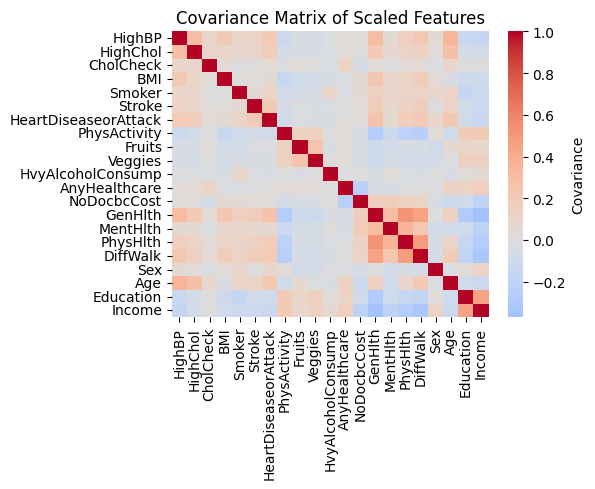

Covariance matrix shape: (21, 21)


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcola la matrice di covarianza
cov_matrix = np.cov(scaled_data.T)

# Crea heatmap delle covarianze
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.savefig("images/covariance_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

# PCA

Applicazione della PCA per analizzare la varianza spiegata da ciascuna componente principale.

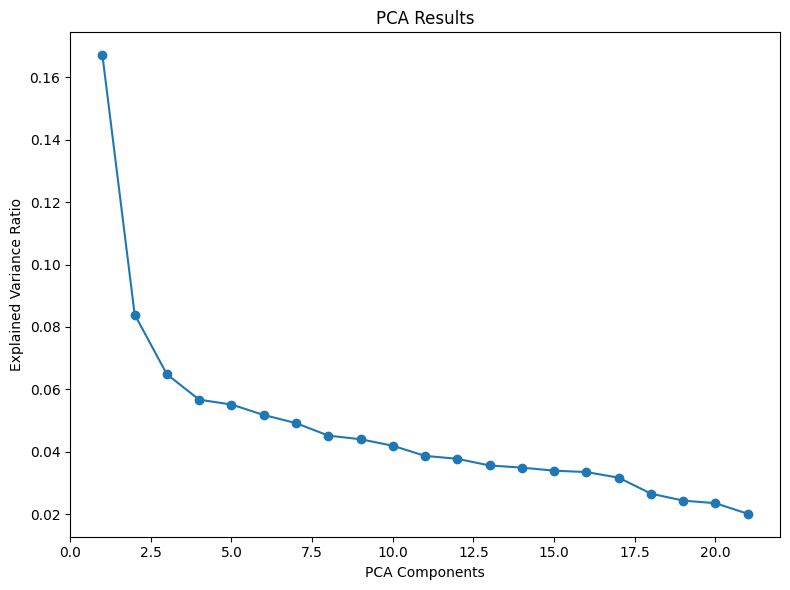

In [15]:
from sklearn.decomposition import PCA

# Applica PCA su tutte le componenti
pca = PCA().fit(scaled_data)

# Visualizza varianza spiegata per componente
plt.figure(figsize=(8, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.tight_layout()
plt.savefig("images/pca_explained_variance.svg", format="svg", bbox_inches="tight")
plt.show()

Determinazione del numero di componenti necessarie per spiegare almeno l'80% della varianza totale.

In [16]:
# Visualizza il ratio di varianza spiegata da ciascuna componente
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [17]:
# Calcola il numero di componenti per spiegare almeno 80% varianza
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 80% variance: {n_components}")

Number of components to explain at least 80% variance: 14


Trasformazione dei dati utilizzando il numero ottimale di componenti principali identificate.

In [18]:
# Applica PCA con n_components ottimale e trasforma i dati
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


### PCA Heatmap e Matrice di Covarianza

Visualizzazione heatmap delle componenti PCA per mostrare il contributo di ciascuna feature originale.

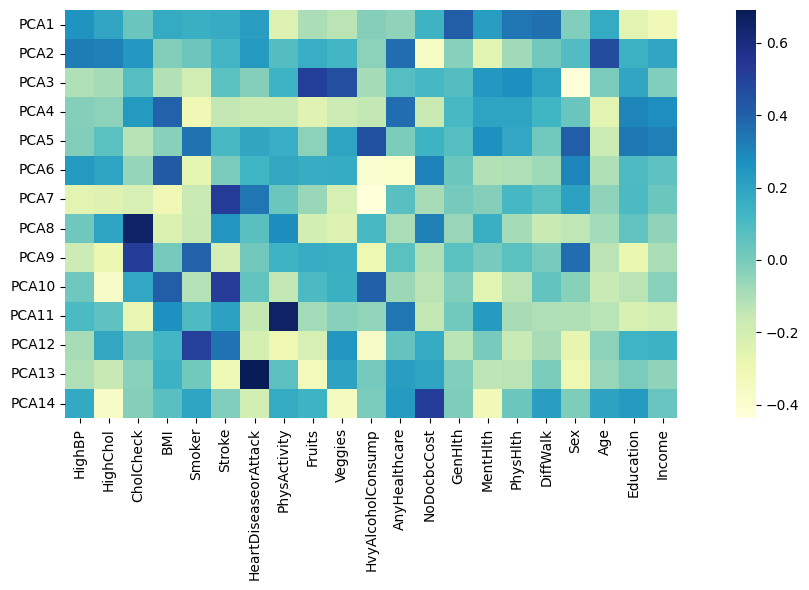

In [19]:
plt.figure(figsize=(12, 6))
# Crea heatmap dei pesi delle componenti
ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("images/pca_components_heatmap.svg", format="svg", bbox_inches="tight")
plt.show()

### Data Splitting

Suddivisione dei dati trasformati con PCA in training e test set per la validazione dei modelli.

In [20]:
# Prepara dati PCA per lo splitting
X_pca = pca_data
y = df["Diabetes_binary"].values

# Split 70-30 sui dati PCA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_pca.shape}")

Dimensioni Training Set: (177576, 14)


# Reti Neurali

Importazione delle librerie necessarie per la creazione e il training delle reti neurali.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf

Funzione di valutazione completa per analizzare le performance dei modelli di rete neurale.

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    """Valuta e visualizza le performance di un modello di rete neurale"""
    
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Predice probabilità e applica threshold
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Calcola e visualizza matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa metriche di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcola curva ROC e AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    # Baseline random classifier
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_roc_curve_{file_suffix}.svg", format="svg", bbox_inches="tight"
    )
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Visualizza loss e accuracy durante training
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"images/nn_training_curves_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

## No PCA

### Standard Dataset

Creazione e training di una rete neurale con architettura sequenziale su dataset standard non bilanciato.

In [23]:
# Crea modello sequenziale con 3 layer nascosti
model = Sequential()

# Layer nascosti: 128 -> 64 -> 32 neuroni con ReLU e Dropout
model.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Layer output con sigmoid per classificazione binaria
model.add(Dense(1, activation="sigmoid"))

# Compila con binary crossentropy
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# Training con 150 epoche e validation split 10%
history = model.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8568 - loss: 0.3416 - val_accuracy: 0.8639 - val_loss: 0.3177
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8628 - loss: 0.3244 - val_accuracy: 0.8646 - val_loss: 0.3170
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8634 - loss: 0.3220 - val_accuracy: 0.8648 - val_loss: 0.3165
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8638 - loss: 0.3207 - val_accuracy: 0.8654 - val_loss: 0.3163
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8643 - loss: 0.3185 - val_accuracy: 0.8647 - val_loss: 0.3161
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8646 - loss: 0.3183 - val_accuracy: 0.8638 - val_loss: 0.3174
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8646 - loss: 0.3178 - val_accuracy: 0.8646 - val_loss: 0.3163
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3163 - val_accu

#### Risultati e Metriche

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 717us/step


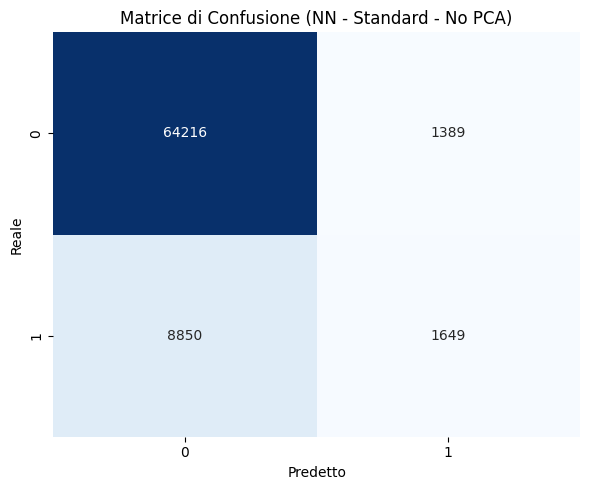

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     65605
           1       0.54      0.16      0.24     10499

    accuracy                           0.87     76104
   macro avg       0.71      0.57      0.58     76104
weighted avg       0.83      0.87      0.83     76104



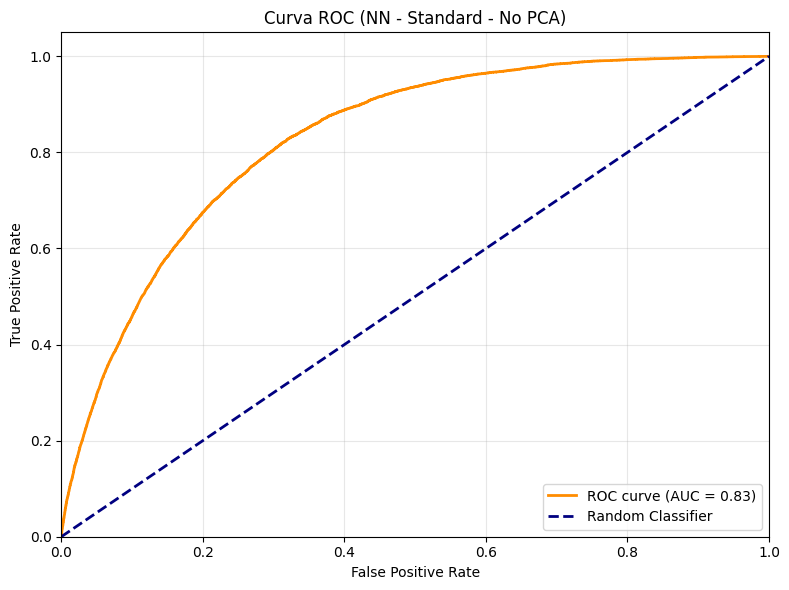


AUC Score: 0.8274


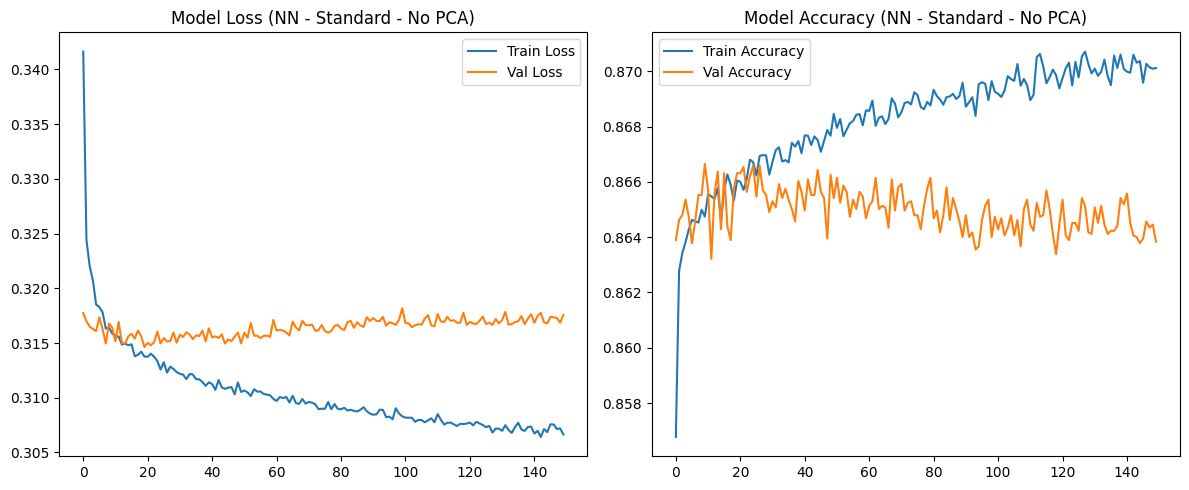

In [24]:
# Valuta il modello e genera grafici delle metriche
evaluate_and_plot(model, X_test, y_test, history, title_suffix="NN - Standard - No PCA")

### Undersampling

Rete neurale con architettura ridotta addestrata su dataset bilanciato tramite undersampling.

In [25]:
# Crea architettura ridotta: 64 -> 32 -> 16
model_undersampling = Sequential()
model_undersampling.add(Dense(64, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_undersampling.add(Dropout(0.5))

model_undersampling.add(Dense(32, activation="relu"))
model_undersampling.add(Dropout(0.3))

model_undersampling.add(Dense(16, activation="relu"))
model_undersampling.add(Dropout(0.3))

model_undersampling.add(Dense(1, activation="sigmoid"))

model_undersampling.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# Training con 100 epoche
history_undersampling = model_undersampling.fit(
    X_train_bal,
    y_train_bal,
    epochs=100,
    batch_size=128,
    verbose=1,
    validation_split=0.1,
)

Epoch 1/100


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6869 - loss: 0.5908 - val_accuracy: 0.7442 - val_loss: 0.5237
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7345 - loss: 0.5431 - val_accuracy: 0.7438 - val_loss: 0.5185
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7400 - loss: 0.5353 - val_accuracy: 0.7448 - val_loss: 0.5119
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7431 - loss: 0.5303 - val_accuracy: 0.7472 - val_loss: 0.5124
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7430 - loss: 0.5280 - val_accuracy: 0.7468 - val_loss: 0.5112
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7464 - loss: 0.5260 - val_accuracy: 0.7480 - val_loss: 0.5139
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7445 - loss: 0.5261 - val_accuracy: 0.7498 - val_loss: 0.5133
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7475 - loss: 0.5227 - val_accuracy: 0.7494

#### Risultati e Metriche

663/663 ━━━━━━━━━━━━━━━━━━━━ 1s 731us/step


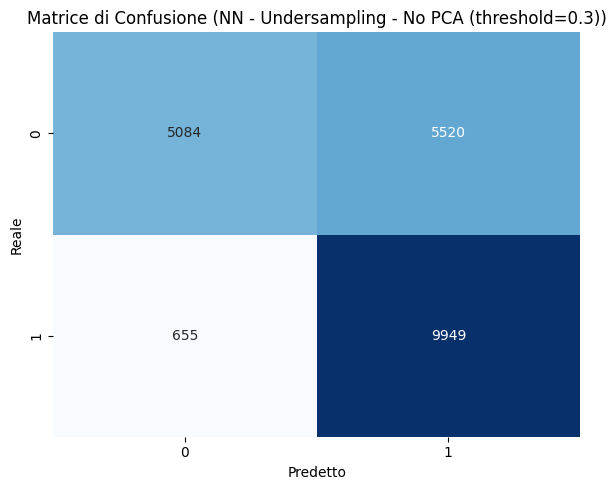

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.89      0.48      0.62     10604
           1       0.64      0.94      0.76     10604

    accuracy                           0.71     21208
   macro avg       0.76      0.71      0.69     21208
weighted avg       0.76      0.71      0.69     21208



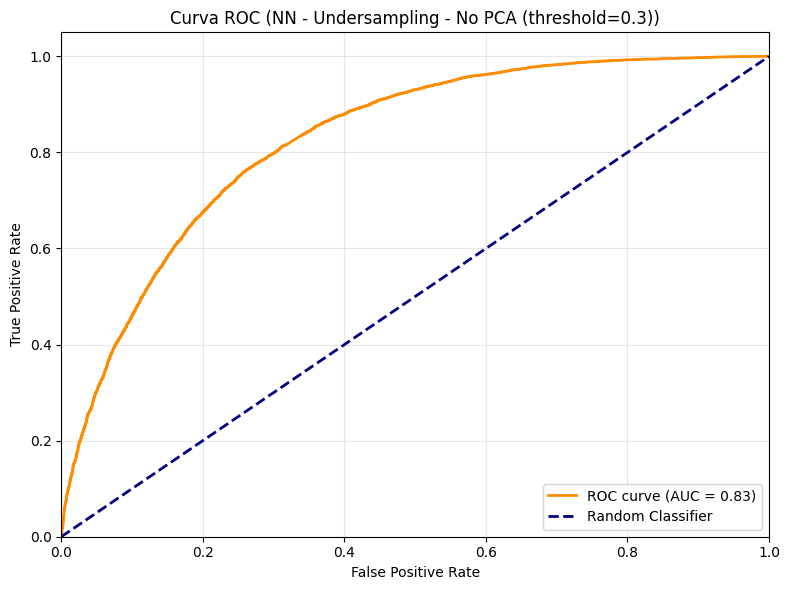


AUC Score: 0.8260


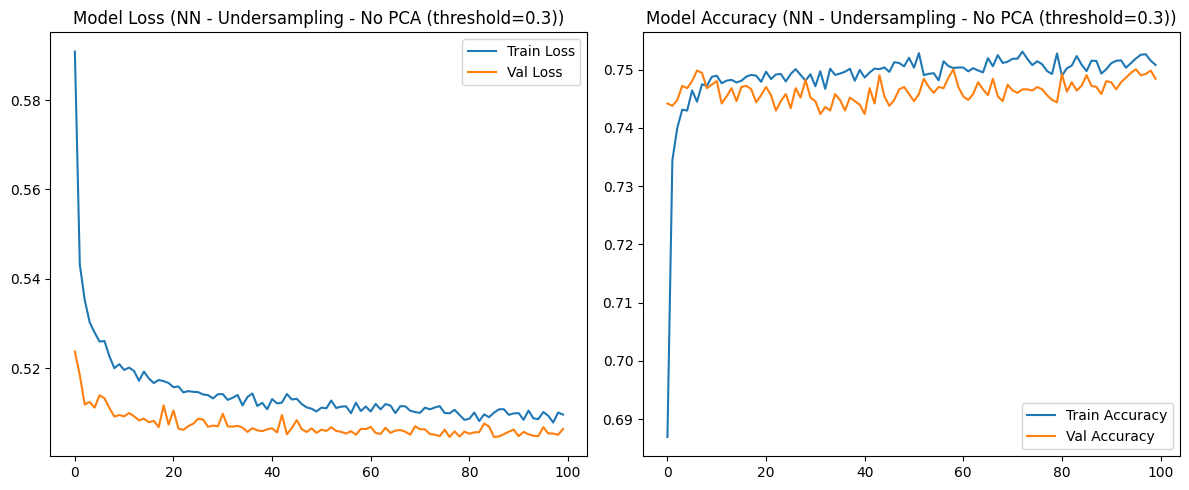

663/663 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step


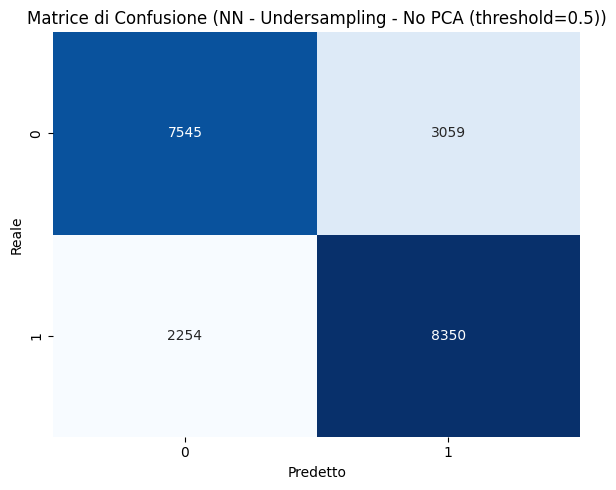

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74     10604
           1       0.73      0.79      0.76     10604

    accuracy                           0.75     21208
   macro avg       0.75      0.75      0.75     21208
weighted avg       0.75      0.75      0.75     21208



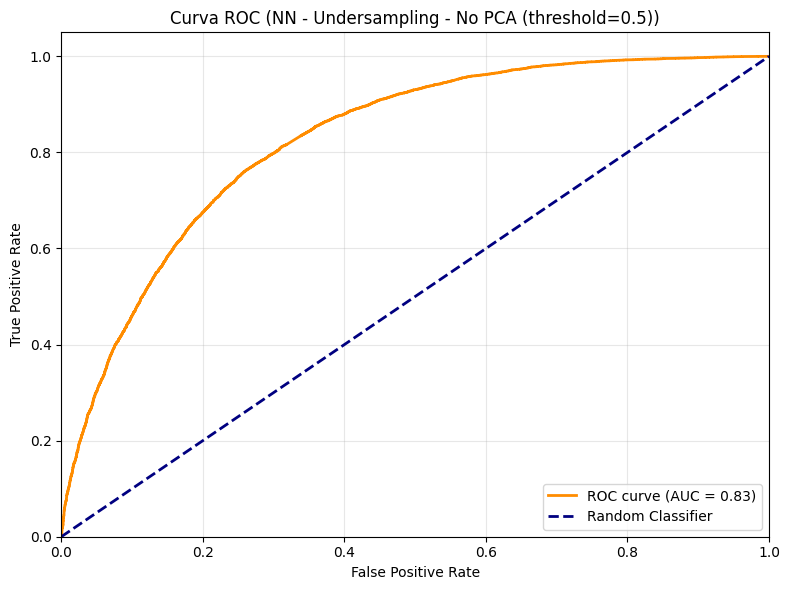


AUC Score: 0.8260


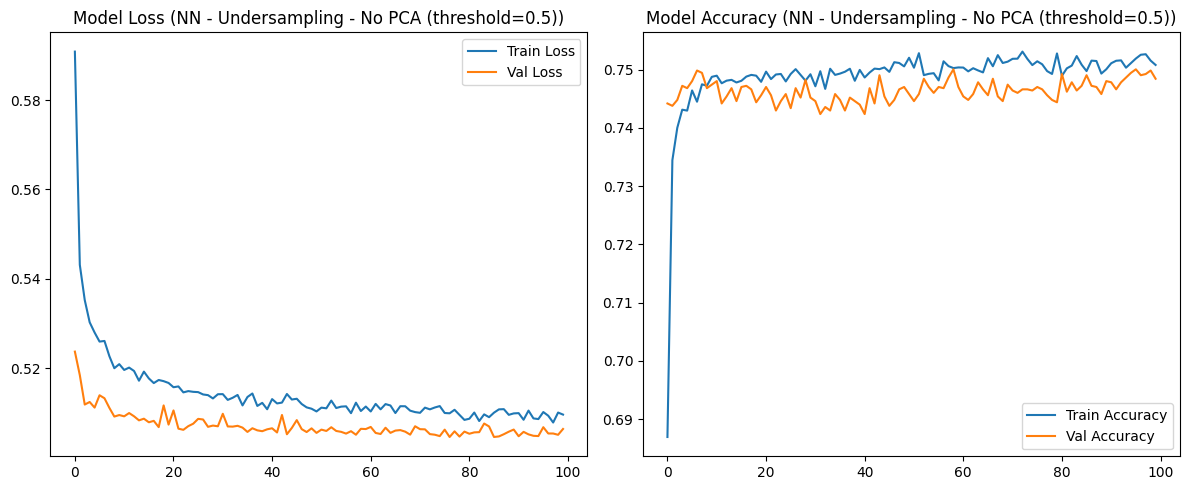

In [26]:
# Testa performance con threshold diversi
for thres in [0.3, 0.5]:
    evaluate_and_plot(
        model_undersampling,
        X_test_bal,
        y_test_bal,
        history_undersampling,
        threshold=thres,
        title_suffix=f"NN - Undersampling - No PCA (threshold={thres})",
    )

### Class Weights

Rete neurale addestrata con pesi di classe bilanciati per gestire lo sbilanciamento durante il training.

In [27]:
# Calcola pesi bilanciati per le classi
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# Architettura: 128 -> 64 -> 32
model_class_weights = Sequential()

model_class_weights.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(64, activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(32, activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(1, activation="sigmoid"))

model_class_weights.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# Training con class_weight
history_class_weights = model_class_weights.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6890 - loss: 0.5368 - val_accuracy: 0.6953 - val_loss: 0.5313
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7045 - loss: 0.5170 - val_accuracy: 0.7154 - val_loss: 0.4967
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7071 - loss: 0.5145 - val_accuracy: 0.7124 - val_loss: 0.5268
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7116 - loss: 0.5118 - val_accuracy: 0.7121 - val_loss: 0.5091
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7136 - loss: 0.5110 - val_accuracy: 0.7264 - val_loss: 0.4982
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7154 - loss: 0.5106 - val_accuracy: 0.7290 - val_loss: 0.4932
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7165 - loss: 0.5099 - val_accuracy: 0.7147 - val_loss: 0.5151
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7185 - loss: 0.5085 - val_accuracy: 0.7335

#### Risultati e Metriche

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 678us/step


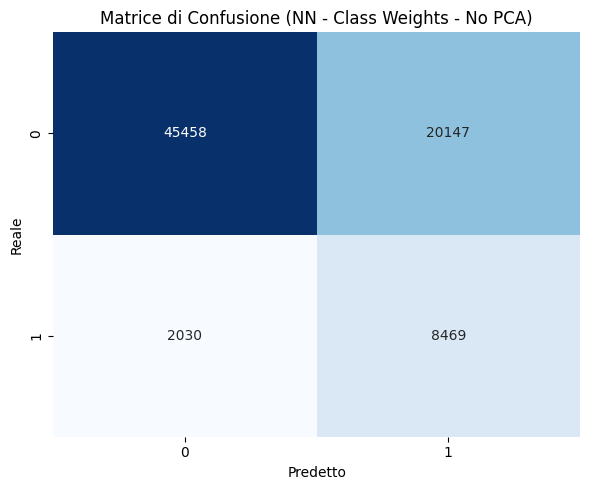

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     65605
           1       0.30      0.81      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.75     76104



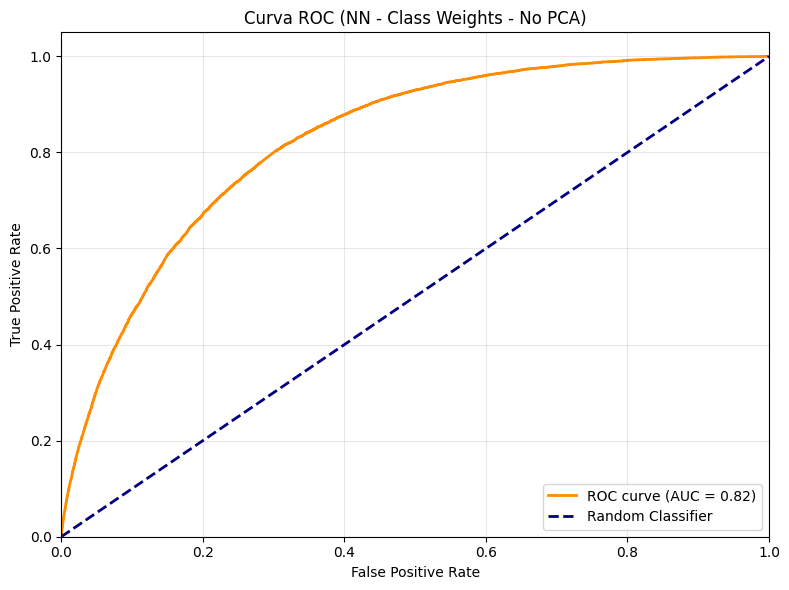


AUC Score: 0.8244


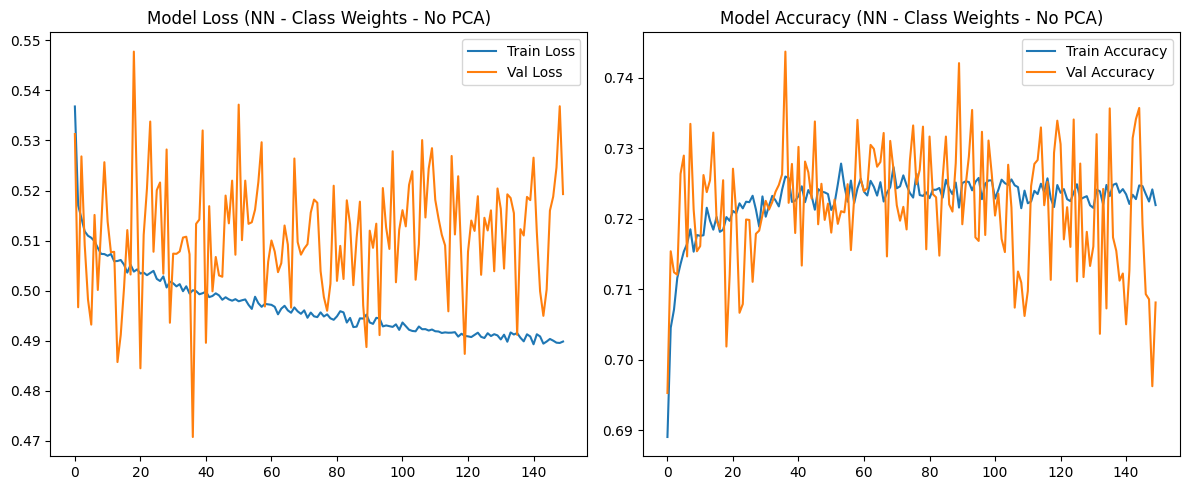

In [28]:
# Valuta modello con class weights
evaluate_and_plot(
    model_class_weights,
    X_test,
    y_test,
    history_class_weights,
    title_suffix="NN - Class Weights - No PCA",
)

## PCA

### Class Weights

Rete neurale ridotta su dati PCA con class weights per bilanciare l'influenza delle classi.

In [29]:
# Calcola class weights per dataset PCA
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_pca), y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# Architettura ridotta: 32 -> 16 -> 8
model_pca_weighted = Sequential()
model_pca_weighted.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(16, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(8, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(1, activation="sigmoid"))

model_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# Training con class weights
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6426 - loss: 0.6127 - val_accuracy: 0.7069 - val_loss: 0.5208
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7114 - loss: 0.5677 - val_accuracy: 0.7148 - val_loss: 0.5094
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7105 - loss: 0.5593 - val_accuracy: 0.7121 - val_loss: 0.5178
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7124 - loss: 0.5539 - val_accuracy: 0.7124 - val_loss: 0.5149
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7106 - loss: 0.5506 - val_accuracy: 0.7051 - val_loss: 0.5099
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7086 - loss: 0.5482 - val_accuracy: 0.7153 - val_loss: 0.5008
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7090 - loss: 0.5465 - val_accuracy: 0.6952 - val_loss: 0.5146
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7090 - loss: 0.5439 - val_accuracy: 0.6936

#### Risultati e Metriche

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 661us/step


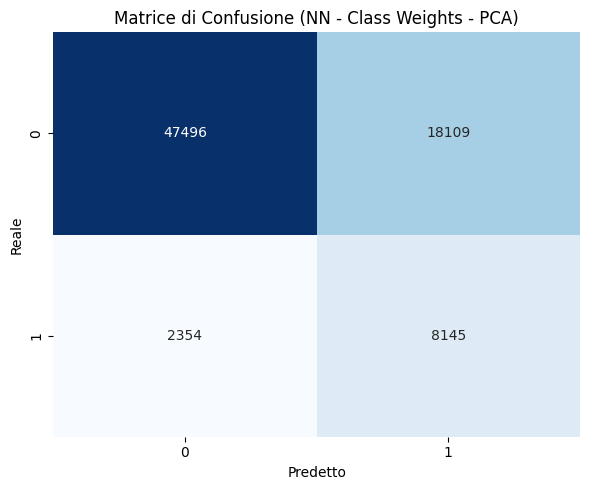

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     65605
           1       0.31      0.78      0.44     10499

    accuracy                           0.73     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.86      0.73      0.77     76104



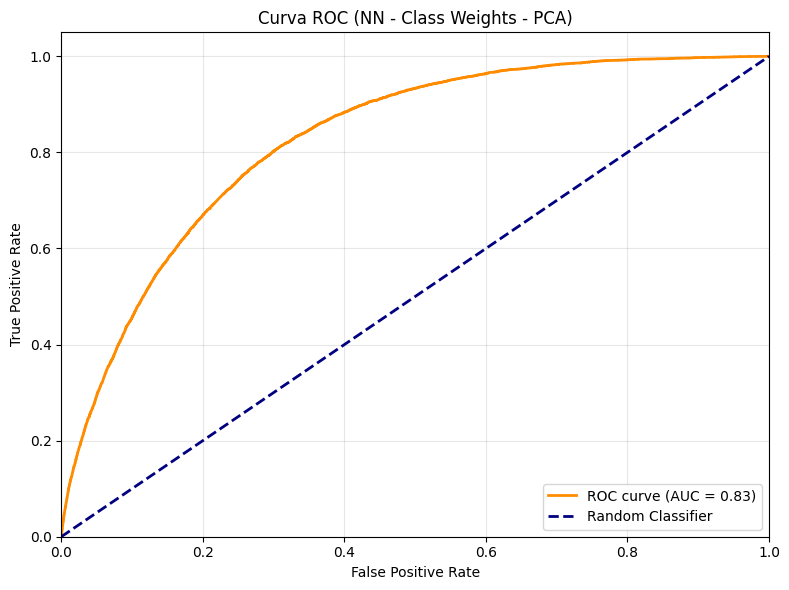


AUC Score: 0.8253


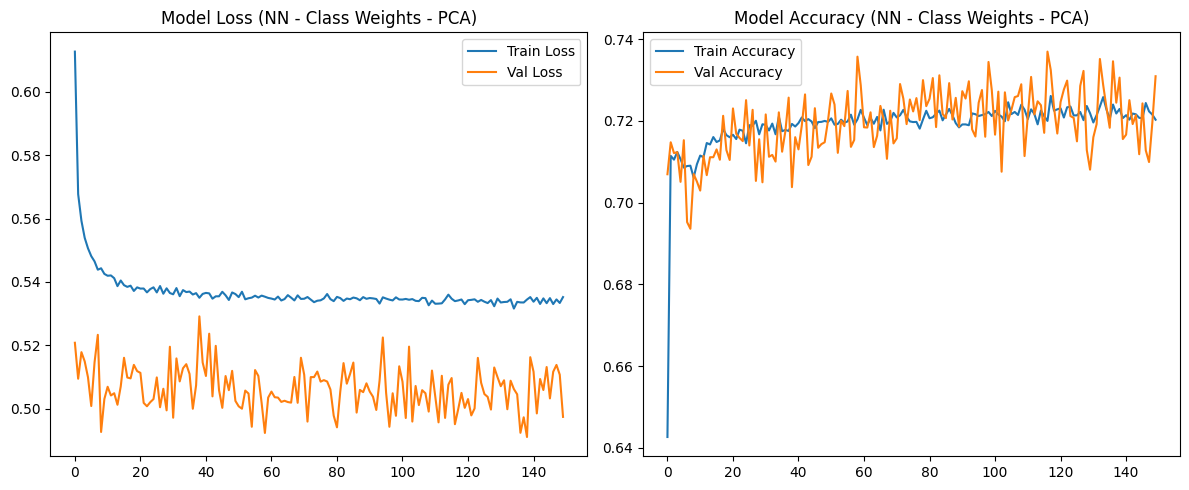

In [30]:
# Valuta modello PCA con class weights
evaluate_and_plot(
    model_pca_weighted,
    X_test_pca,
    y_test_pca,
    history_pca_weighted,
    title_suffix="NN - Class Weights - PCA",
)

# Alberi di Decisione

Definizione delle funzioni di supporto per visualizzazione e valutazione degli alberi di decisione.

In [31]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import re


def show_tree_metrics(tree, y_test, y_pred, title_suffix):
    """Calcola e visualizza le metriche di performance dell'albero"""
    
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    # Caratteristiche strutturali albero
    if hasattr(tree, "get_depth"):
        print(f"Profondità albero: {tree.get_depth()}")
        print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/dt_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    print("\n" + classification_report(y_test, y_pred))


def print_tree(tree, max_depth, title, feature_names=None):
    """Visualizza la struttura dell'albero di decisione"""
    
    if feature_names is None:
        feature_names = numeric_features

    file_suffix = (
        title.lower().replace(" ", "_").replace("-", "") if title else "decision_tree"
    )
    plt.figure(figsize=(50, 24))

    # Genera grafico albero con nodi colorati
    plot_tree(
        tree,
        filled=True,
        feature_names=feature_names,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"images/dt_{file_suffix}.svg", format="svg", bbox_inches="tight")
    plt.show()

Funzione per analizzare e visualizzare l'importanza delle feature nell'albero di decisione.

In [32]:
def plot_feature_importance(tree, feature_names, title_suffix, top_n=None):
    """Visualizza l'importanza delle feature nell'albero"""
    
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Estrae feature importance dall'albero
    importances = tree.feature_importances_

    # Crea DataFrame e ordina per importanza
    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    # Limita alle top_n feature
    if top_n is not None:
        importance_df = importance_df.head(top_n)

    # Crea grafico a barre orizzontali
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(importance_df)), importance_df["importance"])
    plt.yticks(range(len(importance_df)), importance_df["feature"])
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    title = "Feature Importance" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(
        f"images/dt_feature_importance_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa valori
    print(f"\nFeature Importance{' (' + title_suffix + ')' if title_suffix else ''}:")
    print(importance_df.to_string(index=False))

Funzione per eseguire Grid Search con cross-validation per trovare i migliori iperparametri.

In [33]:
def run_grid_search(
    X_train, y_train, param_grid, class_weight="balanced", cv=5, scoring="f1"
):
    """Esegue Grid Search per trovare i migliori iperparametri"""
    
    base_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight)

    # Inizializza Grid Search con cross-validation
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{'='*60}")
    print(f"RISULTATI GRID SEARCH (scoring={scoring}, cv={cv})")
    print(f"{'='*60}")
    print(f"Migliori parametri: {grid_search.best_params_}")
    print(f"Miglior score ({scoring}): {grid_search.best_score_:.4f}")
    print(f"{'='*60}\n")

    return grid_search.best_estimator_, grid_search

Definizione della griglia di iperparametri da testare con Grid Search.

In [34]:
# Griglia iperparametri per Grid Search
dt_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0, 0.0001, 0.0005, 0.001, 0.005, 0.01],
}

## No PCA

### Standard Dataset

Grid Search su dataset standard sbilanciato senza pesi di classe.

In [35]:
# Esegue Grid Search senza class weights
dt_standard, grid_search_standard = run_grid_search(
    X_train, y_train, dt_param_grid, class_weight=None
)
y_pred_standard = dt_standard.predict(X_test)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.3099



#### Risultati e Metriche

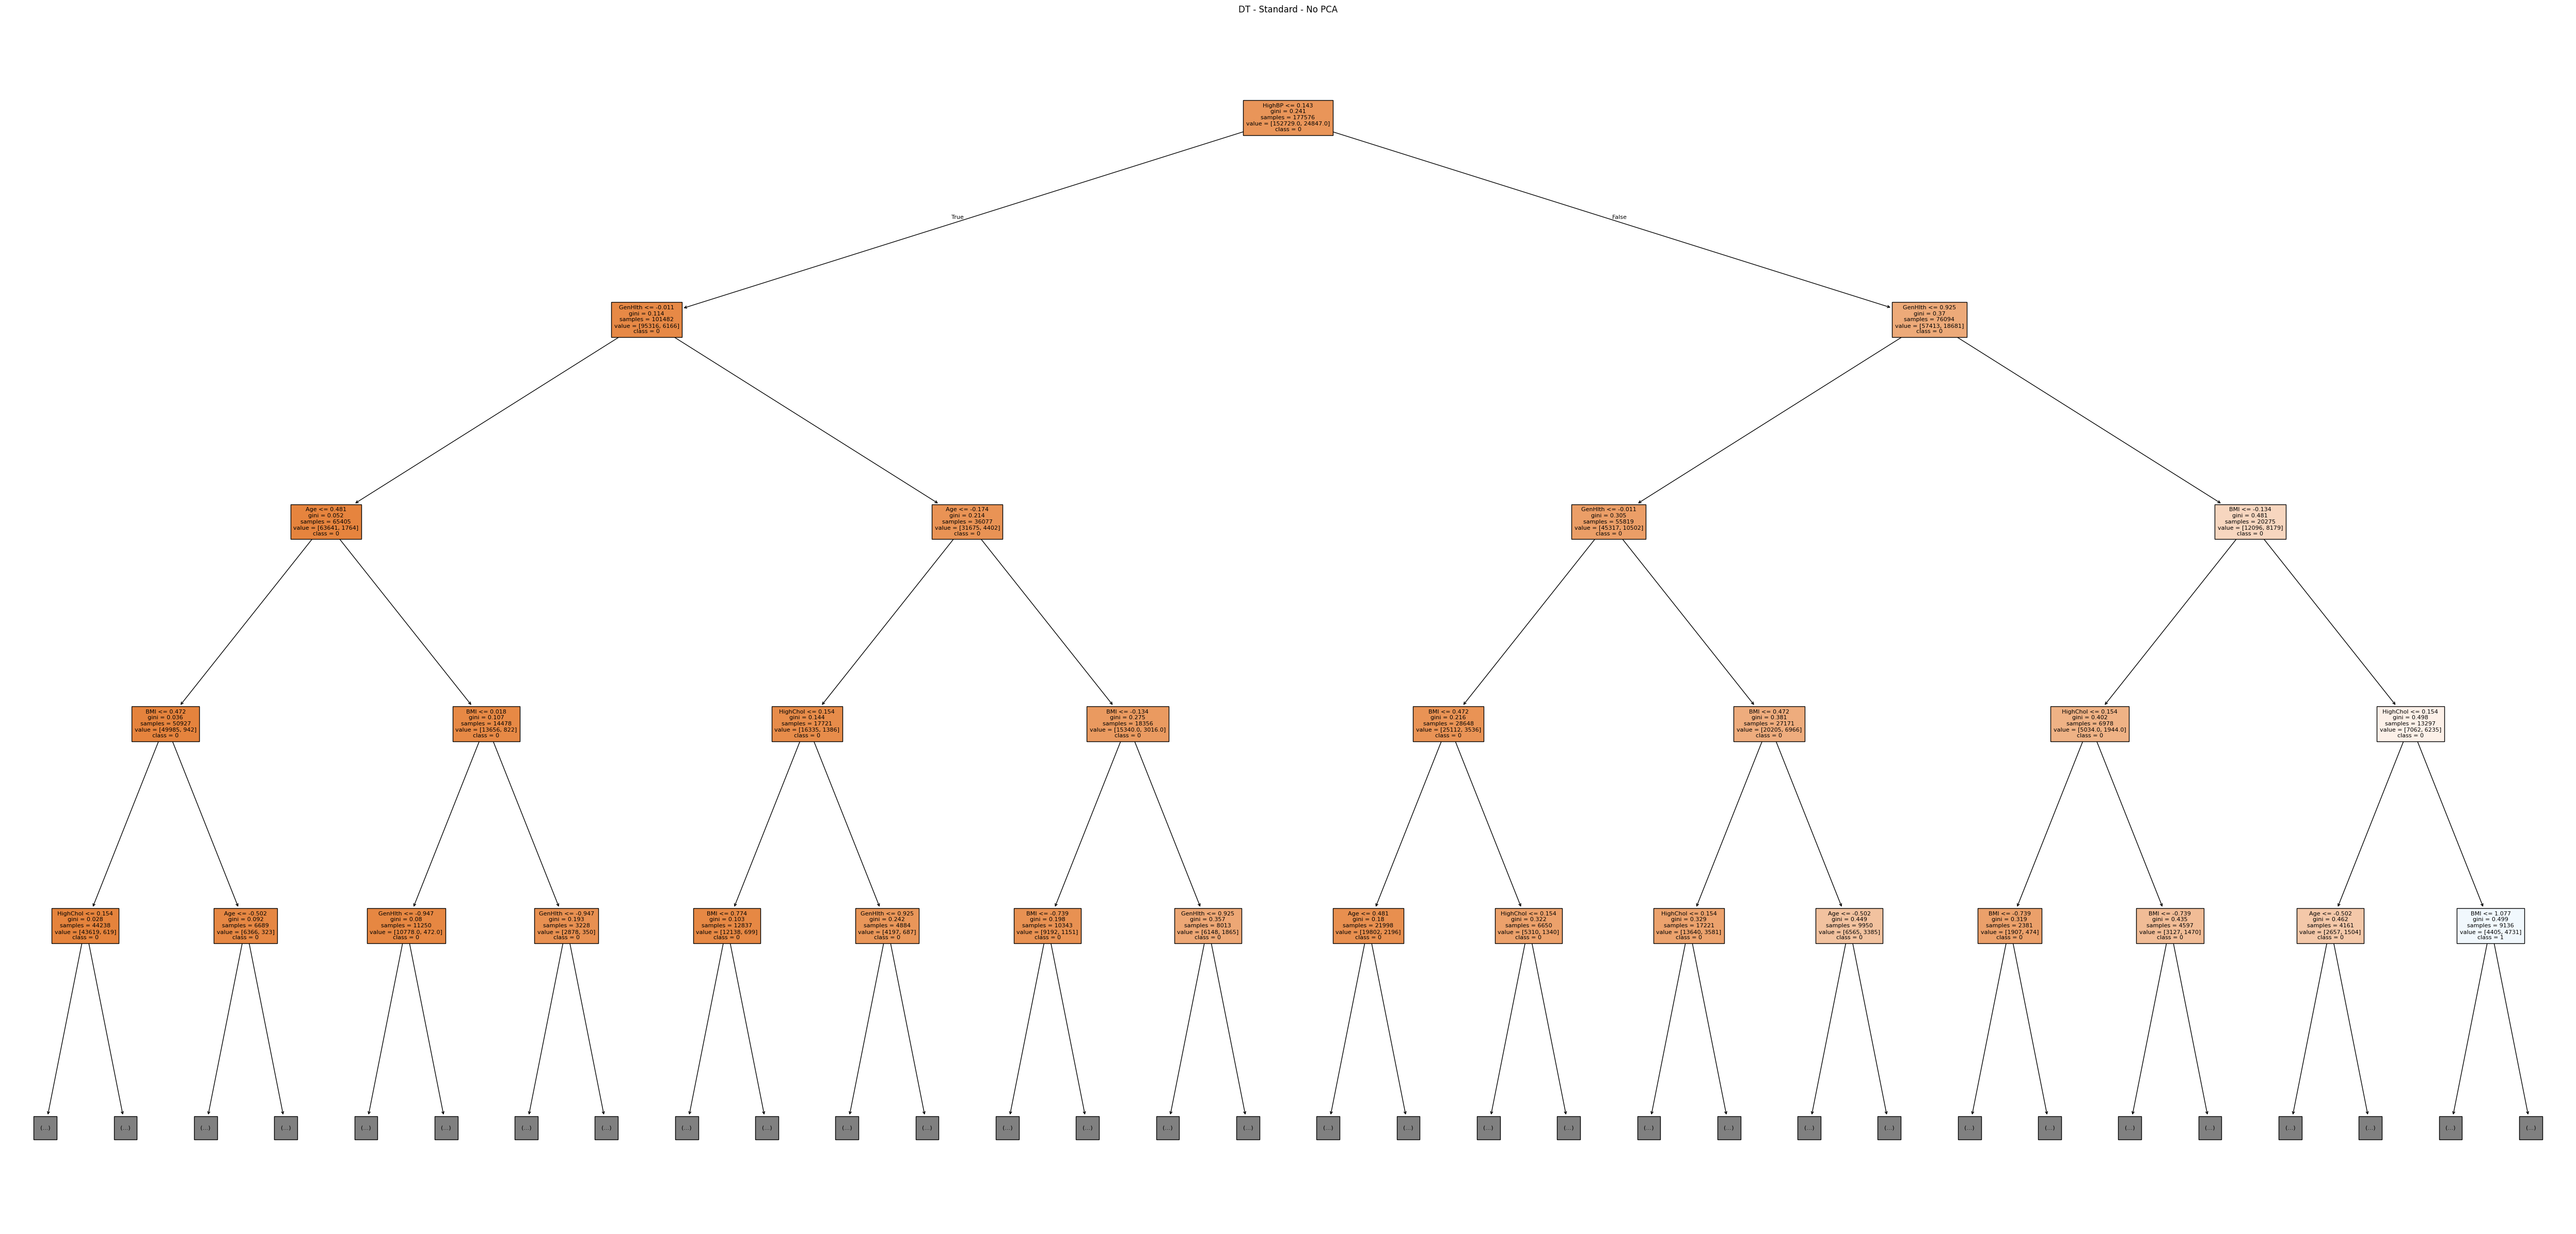

Accuracy: 0.7980
Profondità albero: 38
Numero di foglie: 32829


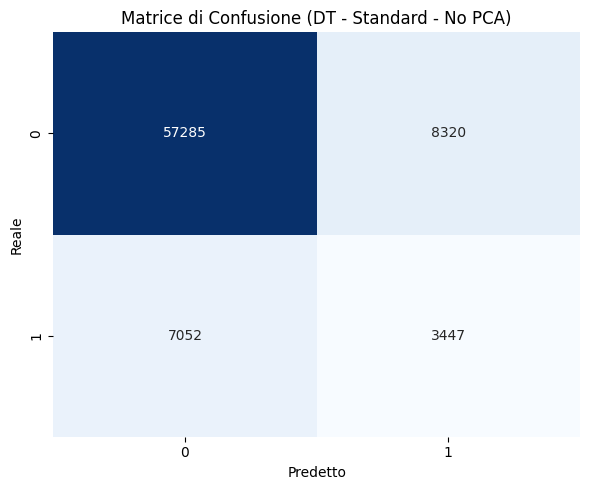


              precision    recall  f1-score   support

           0       0.89      0.87      0.88     65605
           1       0.29      0.33      0.31     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.60     76104
weighted avg       0.81      0.80      0.80     76104



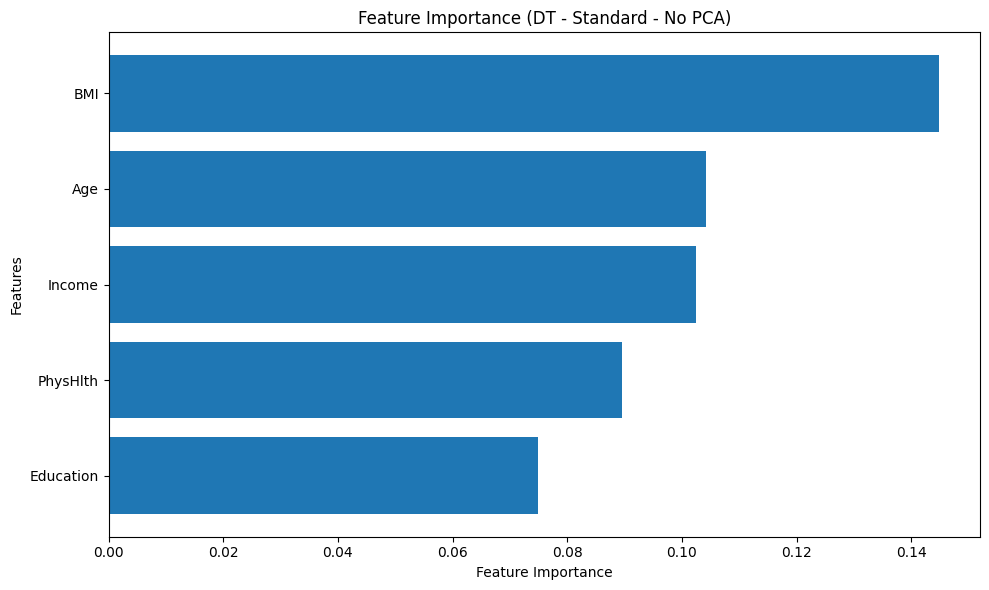


Feature Importance (DT - Standard - No PCA):
  feature  importance
      BMI    0.144732
      Age    0.104101
   Income    0.102435
 PhysHlth    0.089473
Education    0.074885


In [36]:
# Visualizza albero con profondità max 4
print_tree(
    dt_standard,
    max_depth=4,
    title="DT - Standard - No PCA",
    feature_names=numeric_features,
)
show_tree_metrics(
    dt_standard, y_test, y_pred_standard, title_suffix="DT - Standard - No PCA"
)
plot_feature_importance(
    dt_standard,
    feature_names=numeric_features,
    title_suffix="DT - Standard - No PCA",
    top_n=5,
)

### Balanced Dataset

Grid Search e training su dataset bilanciato tramite undersampling.

In [37]:
# Grid Search su dataset bilanciato
dt_undersampling, grid_search_undersampling = run_grid_search(
    X_train_bal,
    y_train_bal,
    dt_param_grid,
    class_weight=None,
    scoring="f1",
)

y_pred_undersampling = dt_undersampling.predict(X_test_bal)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.0001, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.7506



#### Risultati e Metriche

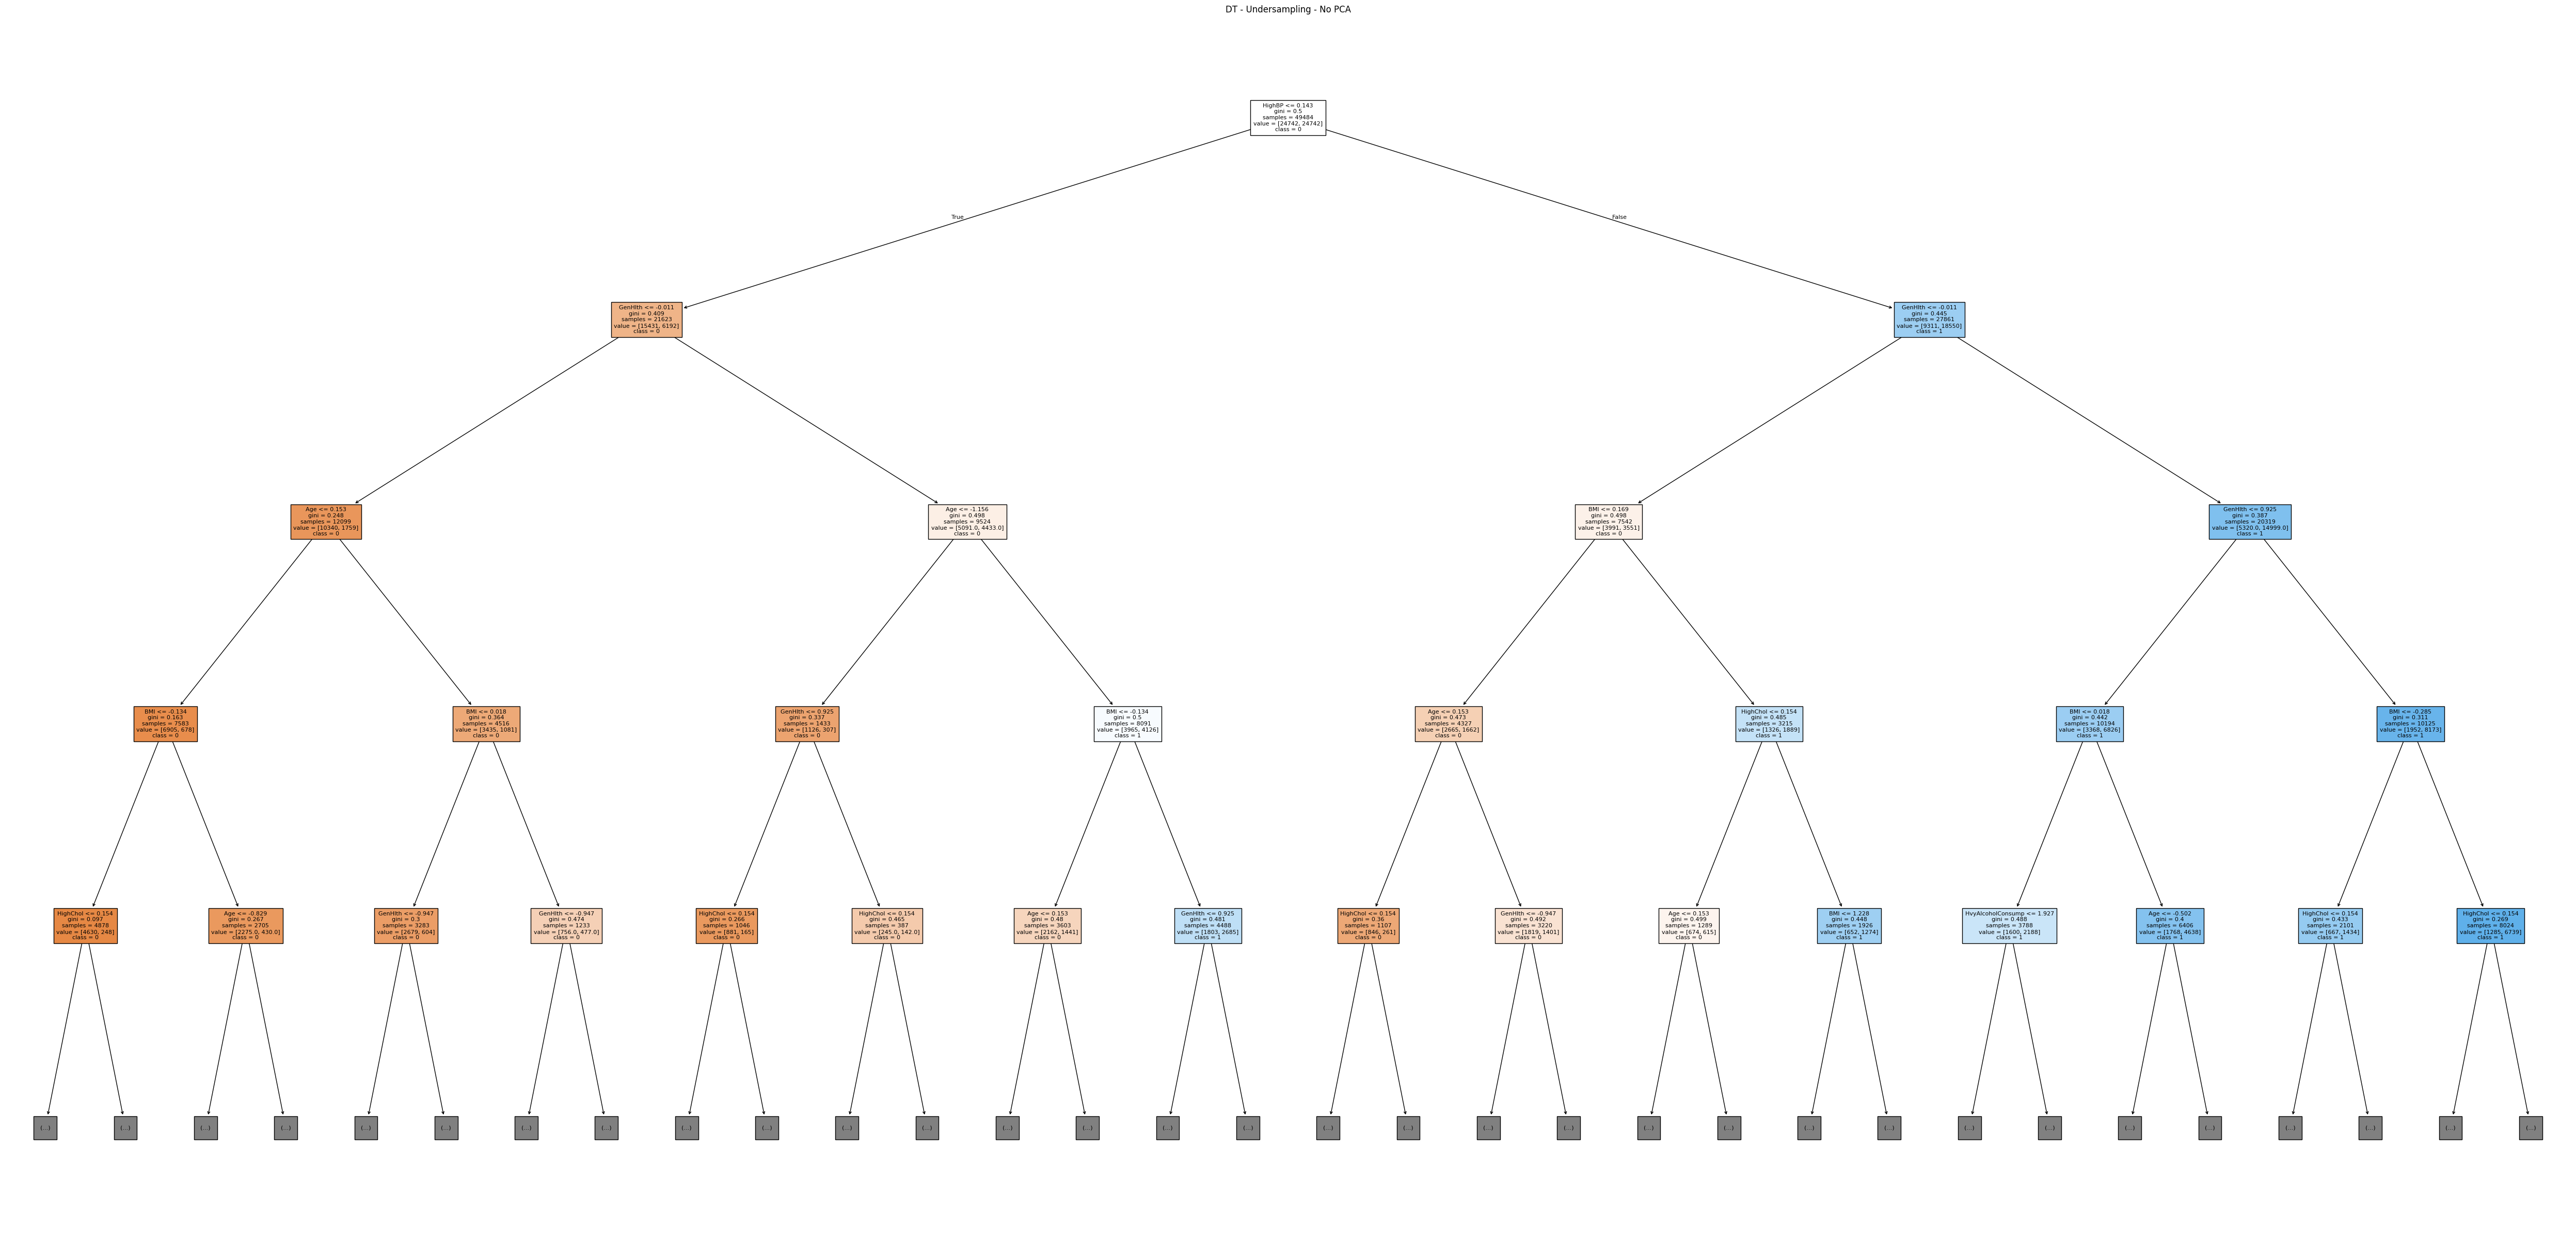

Accuracy: 0.7373
Profondità albero: 10
Numero di foglie: 112


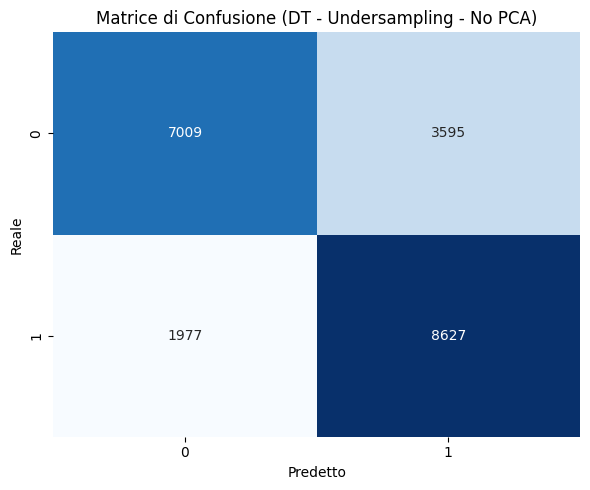


              precision    recall  f1-score   support

           0       0.78      0.66      0.72     10604
           1       0.71      0.81      0.76     10604

    accuracy                           0.74     21208
   macro avg       0.74      0.74      0.74     21208
weighted avg       0.74      0.74      0.74     21208



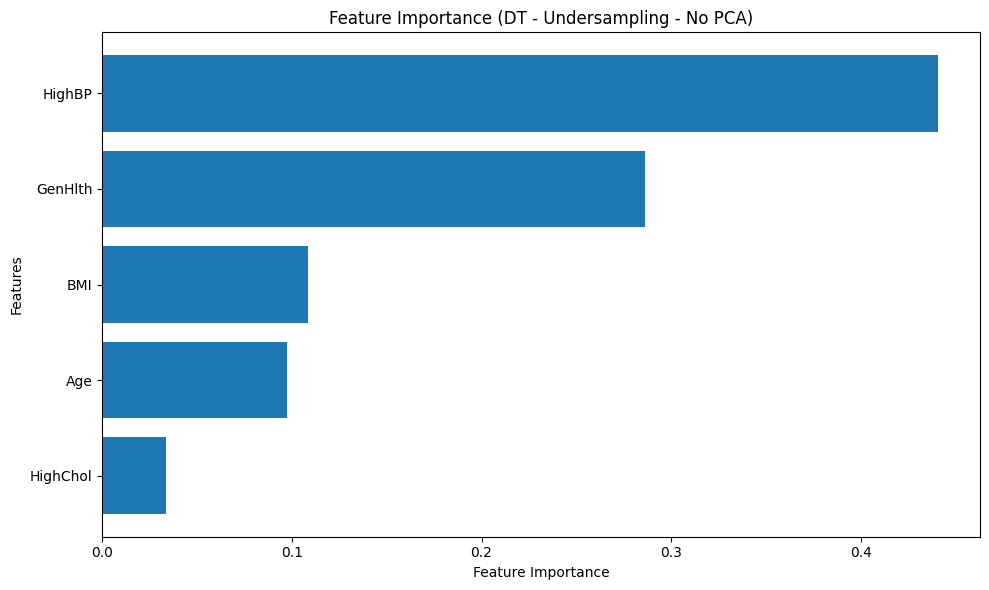


Feature Importance (DT - Undersampling - No PCA):
 feature  importance
  HighBP    0.440687
 GenHlth    0.286156
     BMI    0.108591
     Age    0.097335
HighChol    0.033676


In [38]:
# Visualizza albero su dataset bilanciato
print_tree(dt_undersampling, 4, f"DT - Undersampling - No PCA")
show_tree_metrics(
    dt_undersampling, y_test_bal, y_pred_undersampling, "DT - Undersampling - No PCA"
)
plot_feature_importance(
    dt_undersampling, numeric_features, "DT - Undersampling - No PCA", top_n=5
)

### Class Weight

Grid Search con class weights per gestire lo sbilanciamento delle classi.

In [39]:
# Grid Search con class_weight='balanced'
dt_class_weights, grid_search_class_weights = run_grid_search(
    X_train, y_train, dt_param_grid, class_weight="balanced", scoring="f1"
)

y_pred_class_weights = dt_class_weights.predict(X_test)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Miglior score (f1): 0.4310



#### Risultati e Metriche

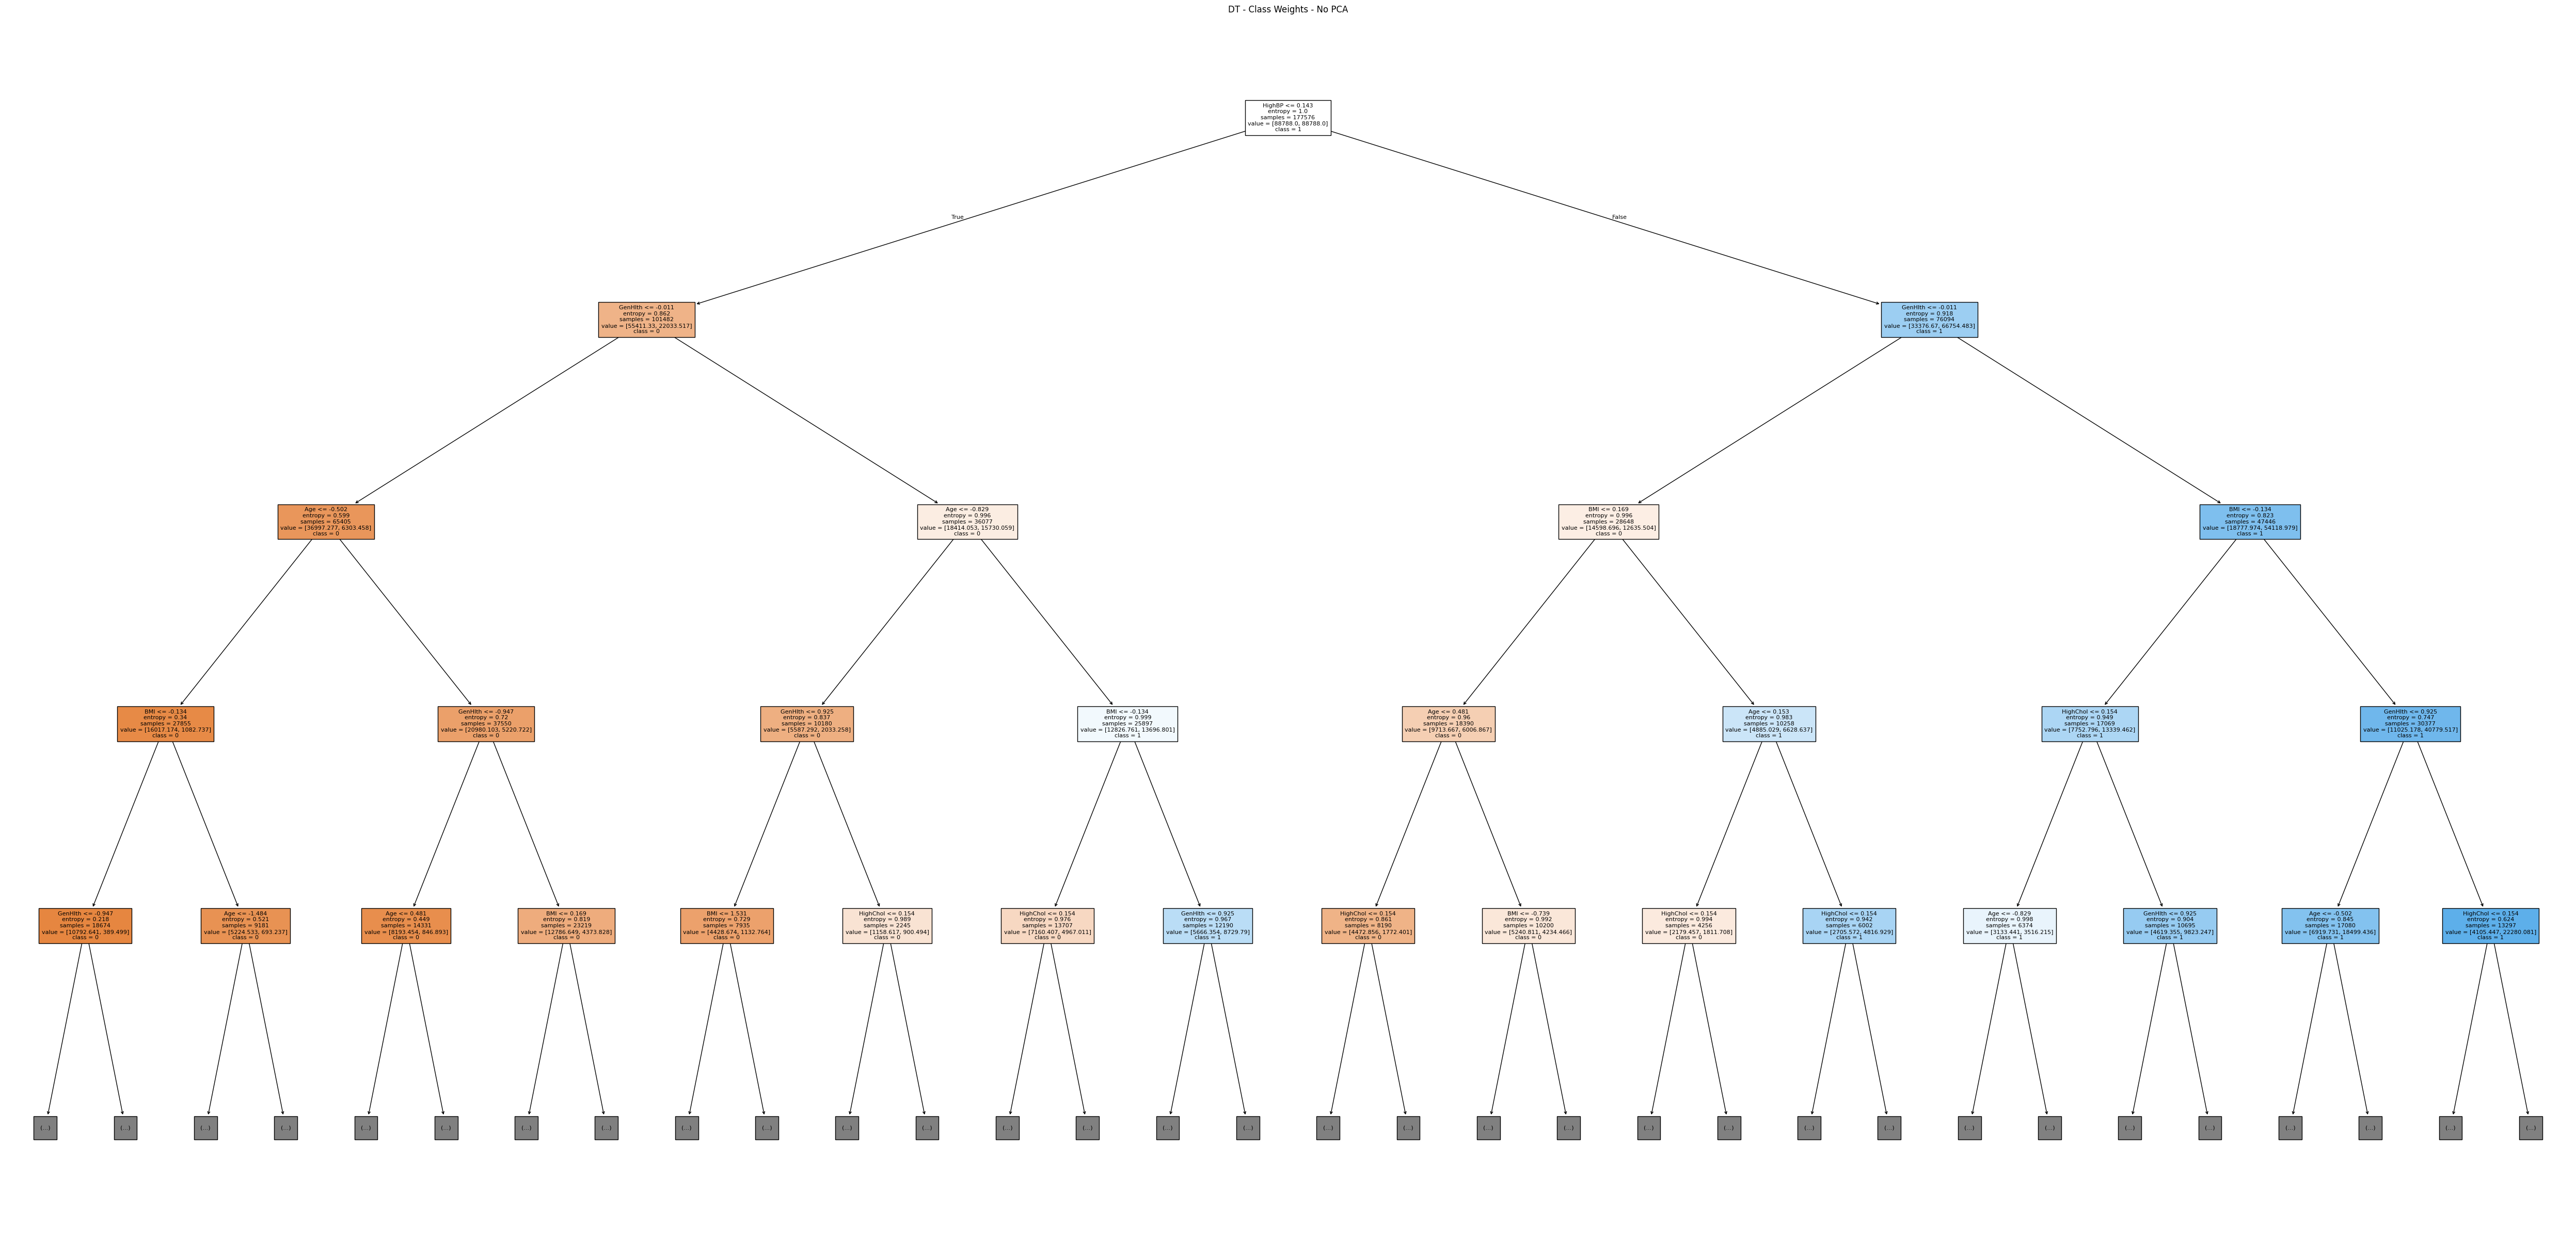

Accuracy: 0.7127
Profondità albero: 10
Numero di foglie: 814


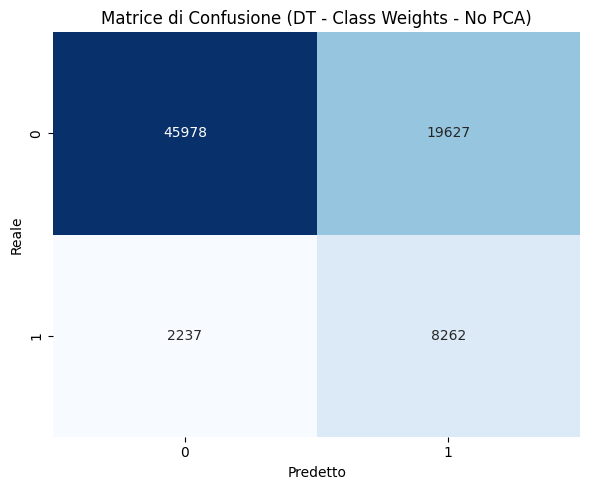


              precision    recall  f1-score   support

           0       0.95      0.70      0.81     65605
           1       0.30      0.79      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.62      0.74      0.62     76104
weighted avg       0.86      0.71      0.76     76104



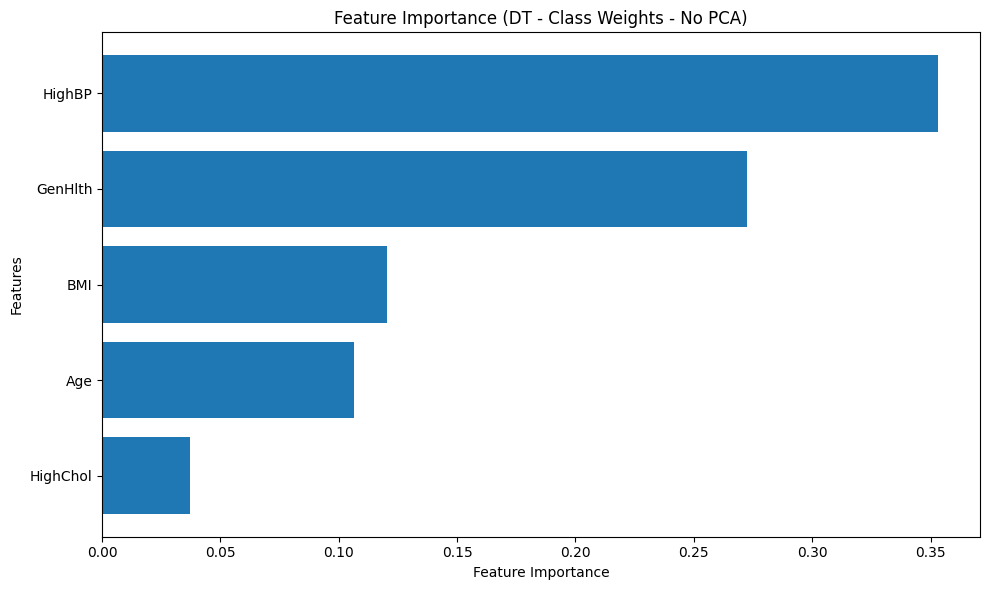


Feature Importance (DT - Class Weights - No PCA):
 feature  importance
  HighBP    0.353217
 GenHlth    0.272532
     BMI    0.120349
     Age    0.106241
HighChol    0.037030


In [40]:
# Visualizza albero con class weights
print_tree(dt_class_weights, 4, f"DT - Class Weights - No PCA")
show_tree_metrics(dt_class_weights, y_test, y_pred_class_weights, "DT - Class Weights - No PCA")

plot_feature_importance(
    dt_class_weights, numeric_features, "DT - Class Weights - No PCA", top_n=5
)

## PCA

### Class Weight

Albero di decisione su dati PCA con iperparametri ottimizzati manualmente.

In [41]:
# Genera nomi per componenti PCA
pca_feature_names = [f"PC{i+1}" for i in range(n_components)]

# Crea albero con iperparametri ottimizzati
dt_pca_class_weights = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=10,
    ccp_alpha=0.0001,
)
dt_pca_class_weights.fit(X_train_pca, y_train_pca)

y_pred_pca_class_weights = dt_pca_class_weights.predict(X_test_pca)

#### Risultati e Metriche

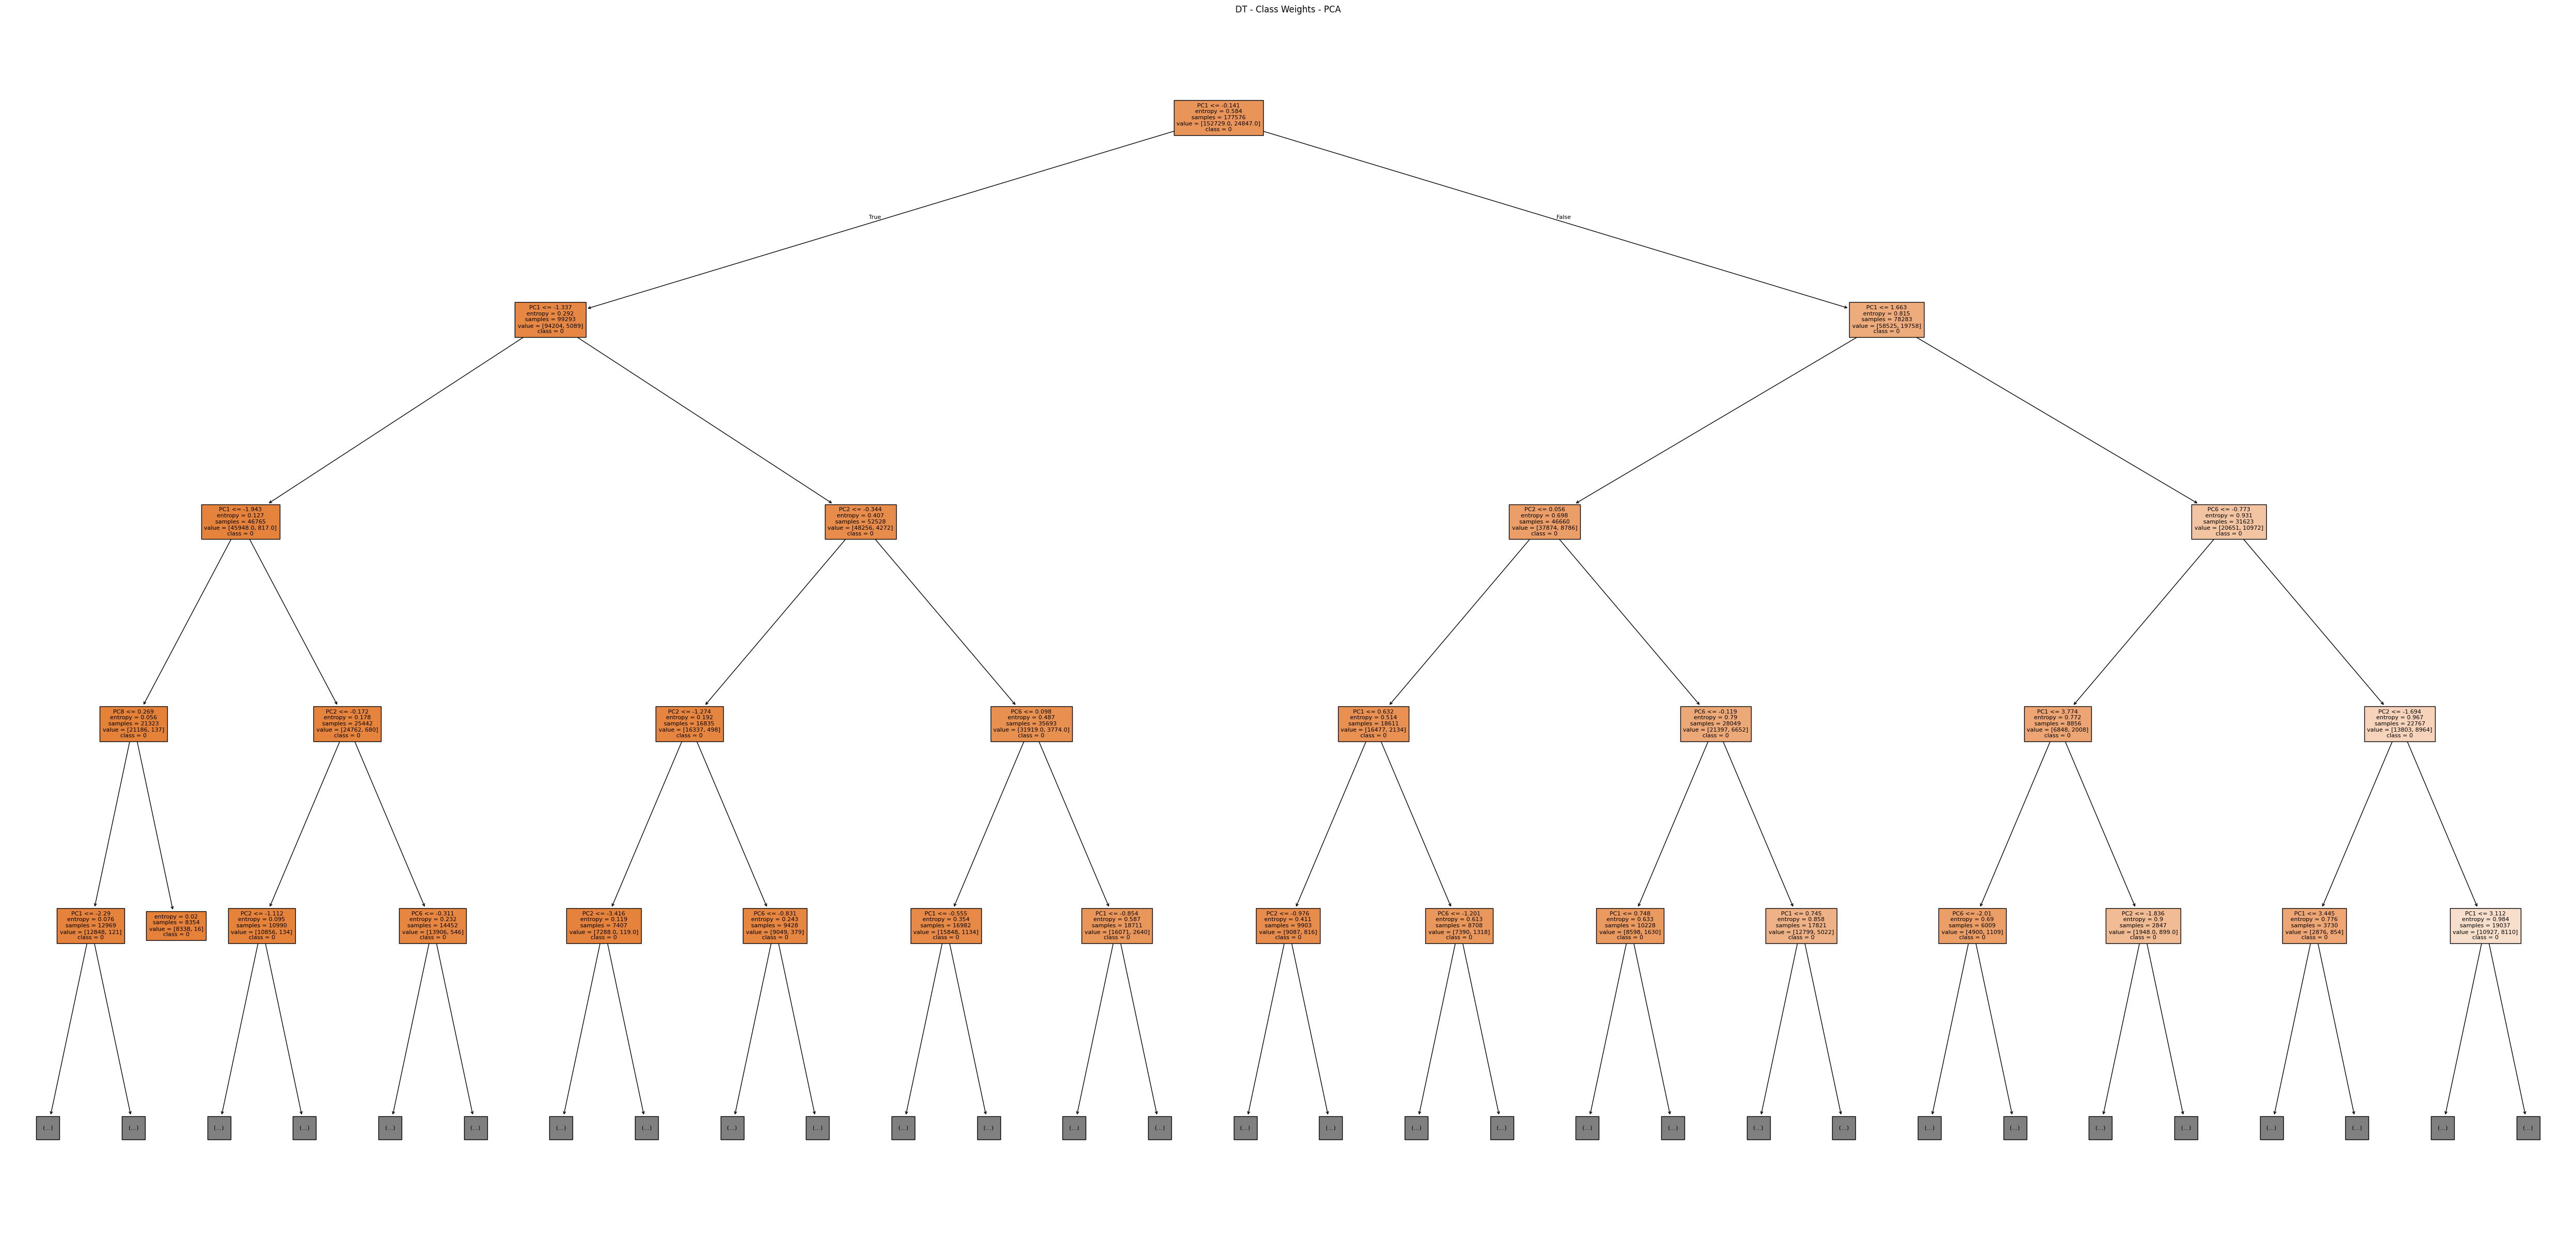

Accuracy: 0.8640
Profondità albero: 9
Numero di foglie: 80


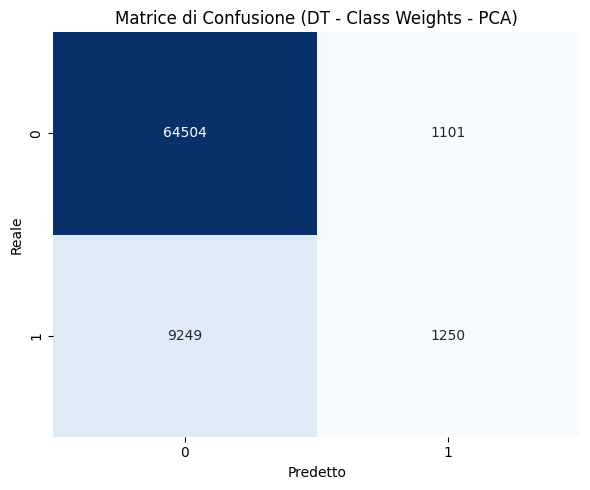


              precision    recall  f1-score   support

           0       0.87      0.98      0.93     65605
           1       0.53      0.12      0.19     10499

    accuracy                           0.86     76104
   macro avg       0.70      0.55      0.56     76104
weighted avg       0.83      0.86      0.82     76104



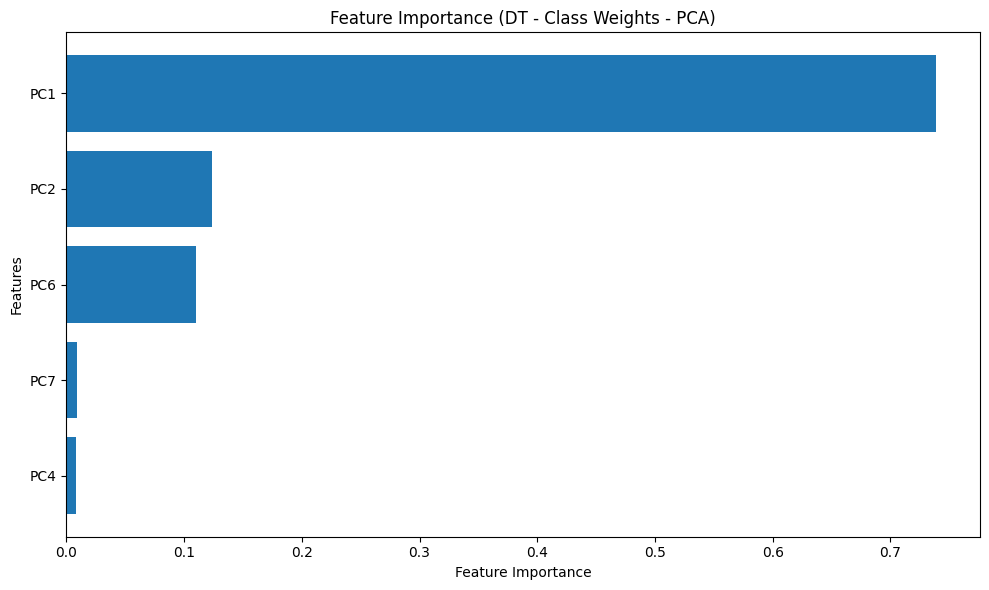


Feature Importance (DT - Class Weights - PCA):
feature  importance
    PC1    0.739073
    PC2    0.124141
    PC6    0.110283
    PC7    0.009037
    PC4    0.007835


In [42]:
# Visualizza albero PCA con nomi componenti
print_tree(
    dt_pca_class_weights,
    4,
    f"DT - Class Weights - PCA",
    feature_names=pca_feature_names,
)
show_tree_metrics(dt_pca_class_weights, y_test_pca, y_pred_pca_class_weights, "DT - Class Weights - PCA")
plot_feature_importance(
    dt_pca_class_weights, pca_feature_names, "DT - Class Weights - PCA", top_n=5
)